# Medical Fact-Checking with HyDE and Russian Clinical Guidelines

Combining HyDE (Hypothetical Document Embeddings) with Russian clinical requirements from cr.minzdrav.gov.ru/clin-rec




This example demonstrates a sophisticated medical fact-checking system that combines:
1. HyDE (Hypothetical Document Embeddings) for improved retrieval
2. Integration with Russian clinical requirements from cr.minzdrav.gov.ru/clin-rec
3. Multi-language support (Russian/English)
4. Knowledge graph reasoning for medical facts

## Как работает HyDE (Hypothetical Document Embeddings)

HyDE (Hypothetical Document Embeddings) — это инновационный подход в информационном поиске, который улучшает релевантность результатов поиска, используя большие языковые модели (LLM) для генерации "гипотетических" ответов на запросы. Вместо того чтобы напрямую сравнивать запрос пользователя с индексированными документами, HyDE создает промежуточный, более информативный "гипотетический документ".

### Основные шаги:

1.  **Генерация гипотетического документа:**
    *   Пользователь задает запрос (например, "Как лечить гипертонию?").
    *   Большая языковая модель (LLM) принимает этот запрос и генерирует подробный, идеальный ответ на него. Этот ответ не является реальным документом из базы знаний, а скорее представляет собой "галлюцинацию" или синтезированное представление того, как мог бы выглядеть идеальный документ, содержащий всю необходимую информацию.
    *   **Пример:** Для запроса "Как лечить гипертонию?" LLM может сгенерировать гипотетический документ, включающий информацию о медикаментозной и немедикаментозной терапии, изменениях образа жизни, целевых показателях давления и важности регулярного мониторинга.

2.  **Создание эмбеддингов (векторных представлений):**
    *   Эмбеддинг-модель (например, BERT, Sentence-BERT или специальные модели эмбеддингов) используется для преобразования **гипотетического документа** в высокоразмерный вектор (эмбеддинг).
    *   Также, все реальные документы в базе знаний (например, клинические рекомендации, статьи) заранее преобразуются в такие же эмбеддинги и индексируются.

3.  **Поиск по эмбеддингам:**
    *   Полученный эмбеддинг гипотетического документа используется для поиска наиболее семантически похожих (ближайших в векторном пространстве) эмбеддингов реальных документов из базы знаний.
    *   Этот поиск обычно осуществляется с использованием методов Approximate Nearest Neighbor (ANN), что позволяет быстро находить релевантные документы даже в очень больших коллекциях.

4.  **Ранжирование и представление результатов:**
    *   Найденные реальные документы, которые семантически близки гипотетическому документу, считаются наиболее релевантными исходному запросу пользователя.
    *   Эти документы затем могут быть представлены пользователю или использованы для дальнейшей обработки (например, для суммаризации, ответа на вопросы).

### Почему HyDE эффективен?

*   **Устранение разрыва в терминологии:** Исходный запрос пользователя может быть кратким или использовать специфическую терминологию, которая отличается от той, что используется в базе знаний. Гипотетический документ, сгенерированный LLM, "расширяет" и "обогащает" запрос, приближая его к содержанию потенциально релевантных документов.
*   **Семантическая глубина:** LLM способны улавливать более глубокий семантический смысл запроса и генерировать документ, который охватывает различные аспекты темы, даже если они не были явно упомянуты в исходном запросе.
*   **Улучшение качества поиска:** За счет генерации более полного и релевантного промежуточного представления, HyDE часто превосходит традиционные методы поиска, основанные только на эмбеддингах исходного запроса.
*   **Снижение зависимости от точного совпадения ключевых слов:** Вместо поиска по ключевым словам, HyDE ориентируется на семантическое сходство, что делает его более устойчивым к вариациям формулировок.

In [ ]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00


In [ ]:
!pip install langchain-mistralai langchain-core langchain-community -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
import requests
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re
from transformers import AutoTokenizer, AutoModel

In [ ]:


# Initialize Mistral LLM (assuming you have your API key configured)
MODEL_NAME = 'mistral-small-latest'
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

🏥 Медицинская проверка фактов с HyDE и клиническими рекомендациями РФ
✅ Медицинская GNN инициализирована

🔍 Начало процесса проверки фактов с использованием HyDE...
Утверждение 1: Гипертония лечится только медикаментами
--------------------------------------------------
🤖 Агент с HyDE обрабатывает...
Generating hypothetical document for: Гипертония лечится только медикаментами
Using HyDE to search for relevant guidelines...


> Entering new AgentExecutor chain...

Invoking: `get_claim_verification_ru` with `{'claim': 'Гипертония лечится только медикаментами', 'language': 'ru'}`


{"claim": "\u0413\u0438\u043f\u0435\u0440\u0442\u043e\u043d\u0438\u044f \u043b\u0435\u0447\u0438\u0442\u0441\u044f \u0442\u043e\u043b\u044c\u043a\u043e \u043c\u0435\u0434\u0438\u043a\u0430\u043c\u0435\u043d\u0442\u0430\u043c\u0438", "status": "REFUTED", "confidence": 0.8, "evidence_summary": "\u0421\u043e\u0433\u043b\u0430\u0441\u043d\u043e \u043a\u043b\u0438\u043d\u0438\u0447\u0435\u0441\u043a\u0438\u043c \u0

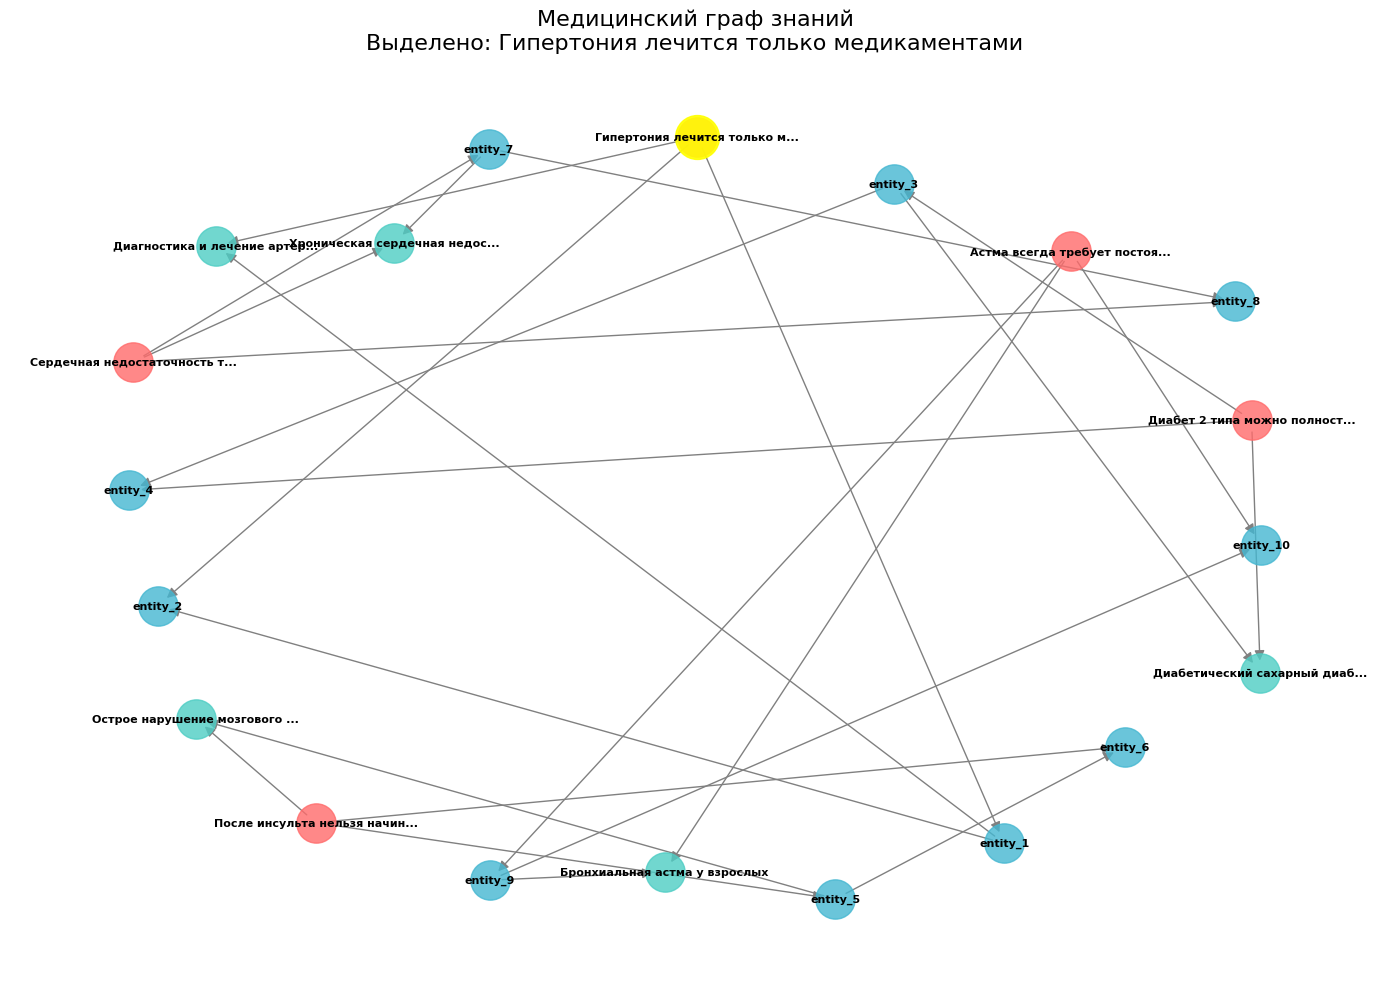



Утверждение 2: Диабет 2 типа можно полностью вылечить диетой
--------------------------------------------------
🤖 Агент с HyDE обрабатывает...
Generating hypothetical document for: Диабет 2 типа можно полностью вылечить диетой
Using HyDE to search for relevant guidelines...


> Entering new AgentExecutor chain...

Invoking: `get_claim_verification_ru` with `{'claim': 'Диабет 2 типа можно полностью вылечить диетой', 'language': 'ru'}`


{"claim": "\u0414\u0438\u0430\u0431\u0435\u0442 2 \u0442\u0438\u043f\u0430 \u043c\u043e\u0436\u043d\u043e \u043f\u043e\u043b\u043d\u043e\u0441\u0442\u044c\u044e \u0432\u044b\u043b\u0435\u0447\u0438\u0442\u044c \u0434\u0438\u0435\u0442\u043e\u0439", "status": "REFUTED", "confidence": 0.9, "evidence_summary": "\u0421\u043e\u0433\u043b\u0430\u0441\u043d\u043e \u043a\u043b\u0438\u043d\u0438\u0447\u0435\u0441\u043a\u0438\u043c \u0440\u0435\u043a\u043e\u043c\u0435\u043d\u0434\u0430\u0446\u0438\u044f\u043c, \u0434\u0438\u0430\u0431\u0435\u0442 2 \u0442\u0438\

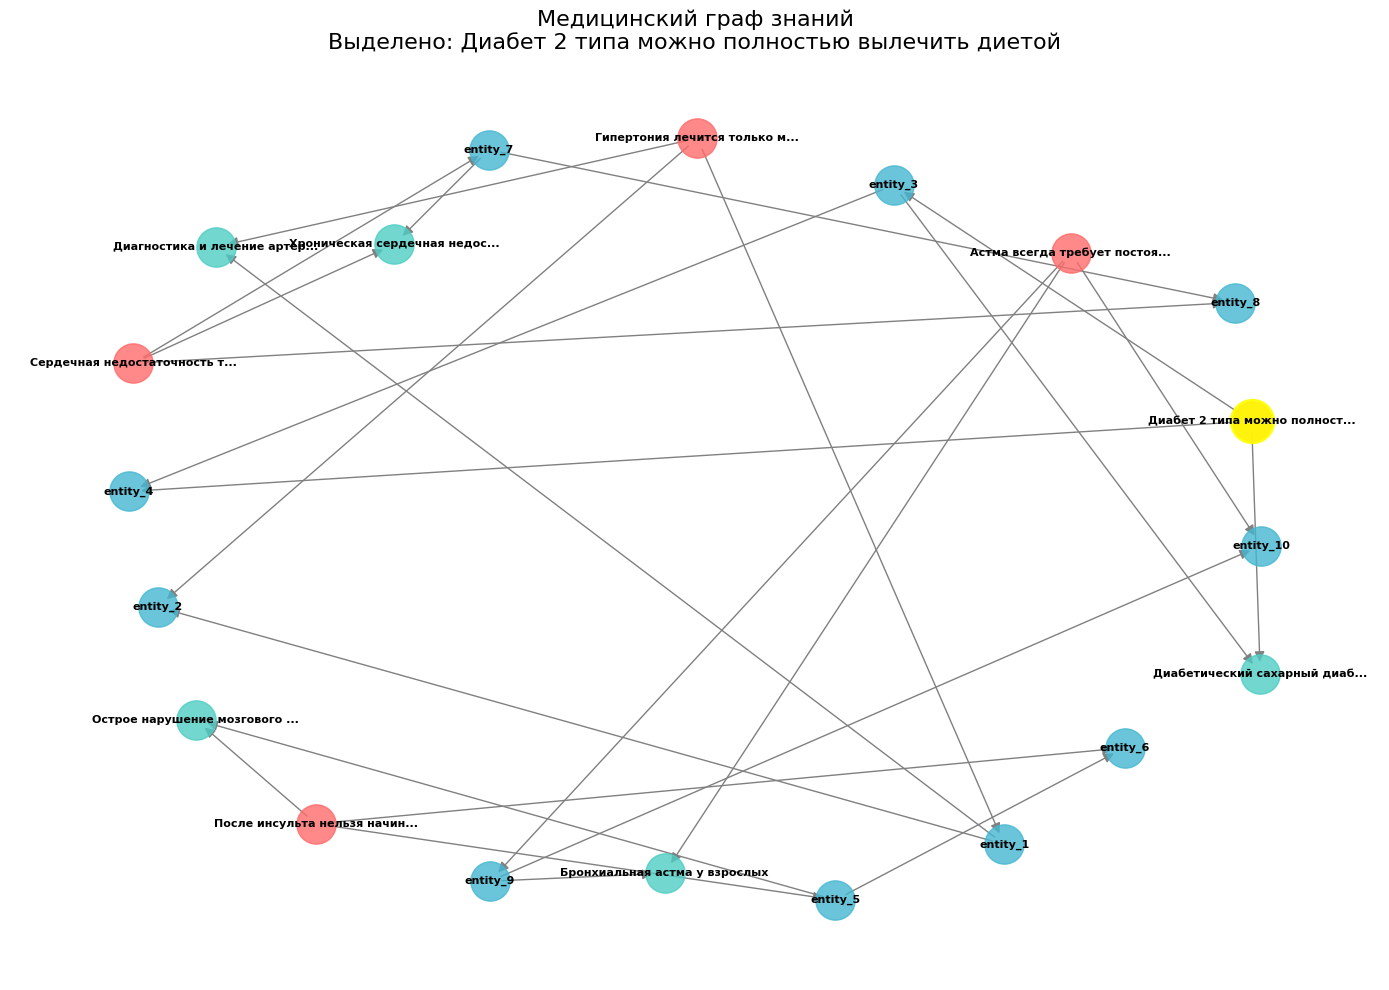



Утверждение 3: После инсульта нельзя начинать реабилитацию сразу
--------------------------------------------------
🤖 Агент с HyDE обрабатывает...
Generating hypothetical document for: После инсульта нельзя начинать реабилитацию сразу
Using HyDE to search for relevant guidelines...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'ранняя реабилитация после инсульта сроки и противопоказания', 'language': 'ru'}`
responded: Для проверки утверждения **"После инсульта нельзя начинать реабилитацию сразу"** с использованием подхода **HyDE**, я выполню следующие шаги:

---

### **Шаг 1: Генерация гипотетического документа**
Гипотетический документ, который идеально ответил бы на запрос, должен содержать:
1. Определение понятия **"ранняя реабилитация после инсульта"**.
2. Клинические рекомендации о **сроках начала реабилитации** в зависимости от типа инсульта (ишемический/геморрагический).
3. Перечень **противопоказаний** для ранней реабил

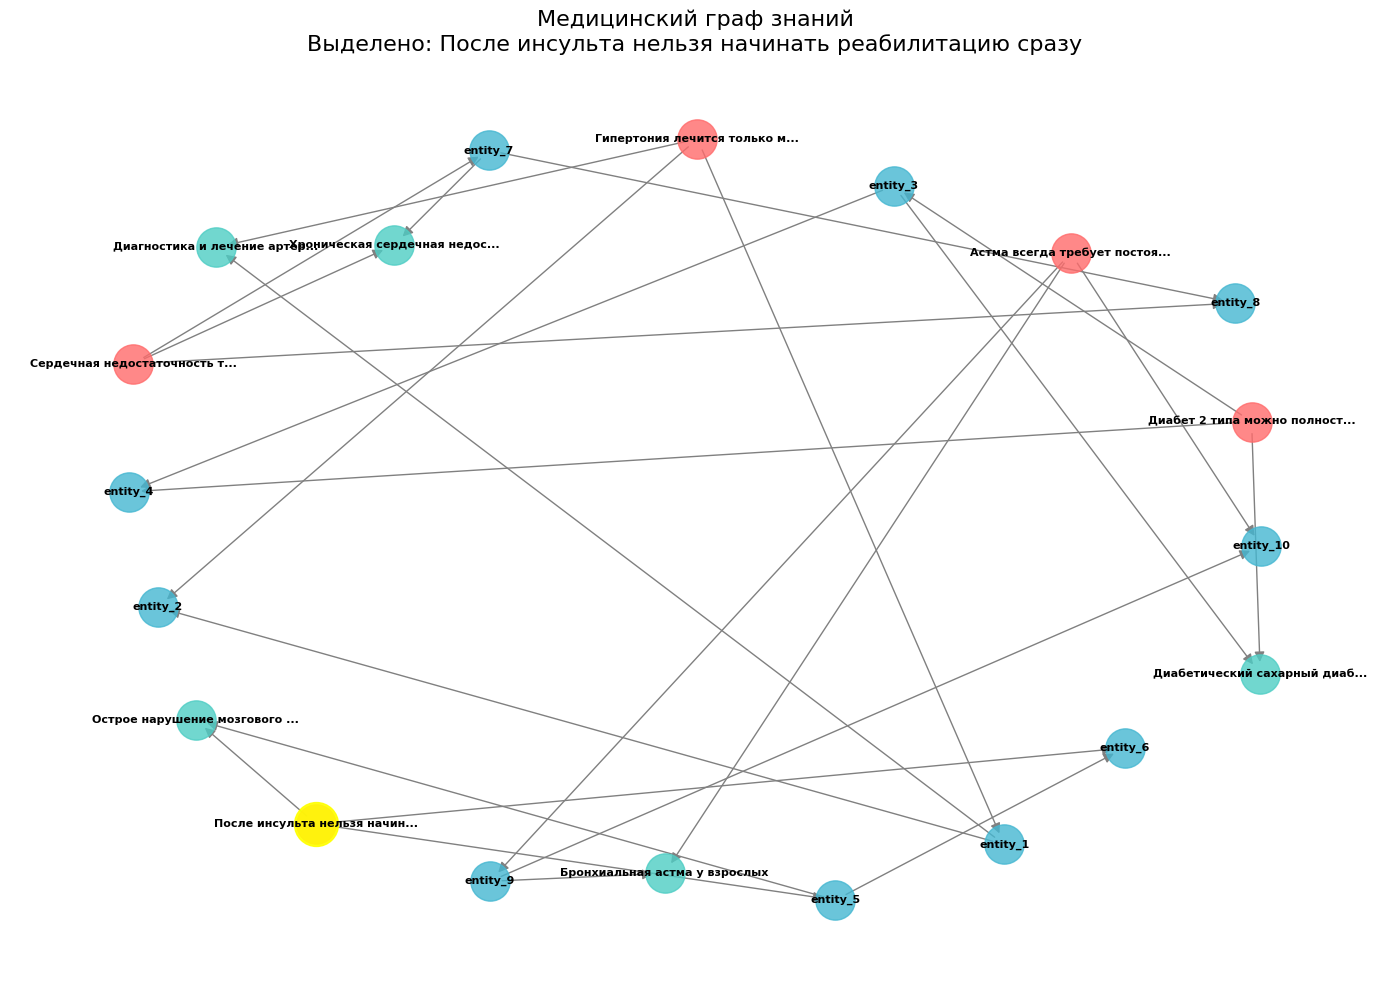



Утверждение 4: Сердечная недостаточность требует строгой диеты с ограничением соли
--------------------------------------------------
🤖 Агент с HyDE обрабатывает...
Generating hypothetical document for: Сердечная недостаточность требует строгой диеты с ограничением соли
Using HyDE to search for relevant guidelines...


> Entering new AgentExecutor chain...

Invoking: `get_claim_verification_ru` with `{'claim': 'Сердечная недостаточность требует строгой диеты с ограничением соли', 'language': 'ru'}`


{"claim": "\u0421\u0435\u0440\u0434\u0435\u0447\u043d\u0430\u044f \u043d\u0435\u0434\u043e\u0441\u0442\u0430\u0442\u043e\u0447\u043d\u043e\u0441\u0442\u044c \u0442\u0440\u0435\u0431\u0443\u0435\u0442 \u0441\u0442\u0440\u043e\u0433\u043e\u0439 \u0434\u0438\u0435\u0442\u044b \u0441 \u043e\u0433\u0440\u0430\u043d\u0438\u0447\u0435\u043d\u0438\u0435\u043c \u0441\u043e\u043b\u0438", "status": "UNVERIFIED", "confidence": 0.0, "evidence_summary": "\u041d\u0435\u0442 \u0432\u0435\u0440\u0438\u04

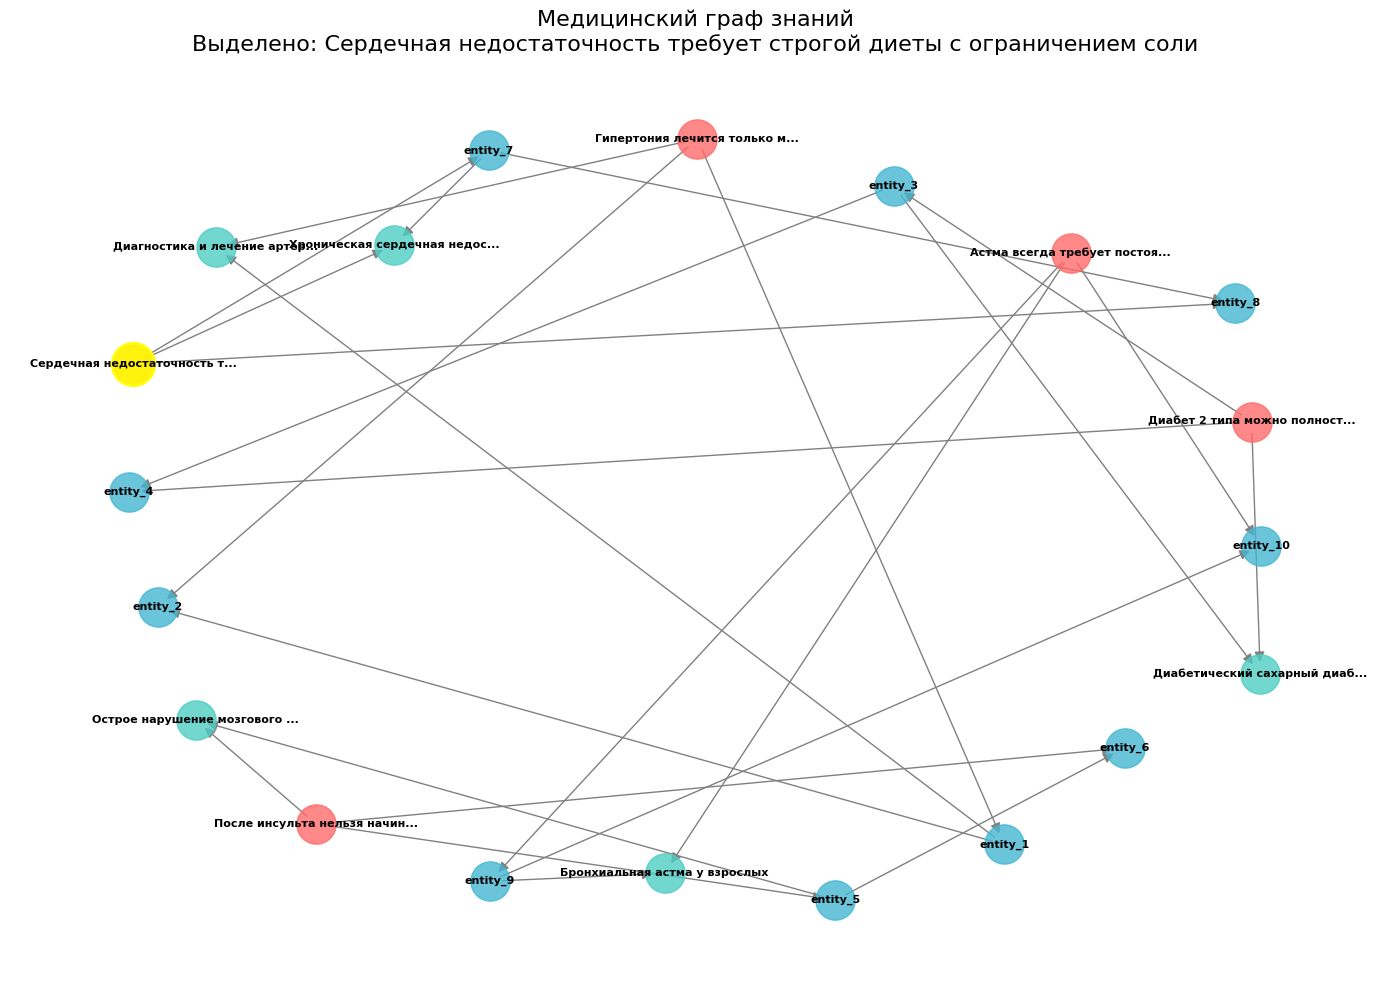



Утверждение 5: Астма всегда требует постоянного приема кортикостероидов
--------------------------------------------------
🤖 Агент с HyDE обрабатывает...
Generating hypothetical document for: Астма всегда требует постоянного приема кортикостероидов
Using HyDE to search for relevant guidelines...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines_ru` with `{'condition': 'бронхиальная астма', 'language': 'ru'}`
responded: ### **Процесс проверки утверждения с использованием подхода HyDE**

#### **1. Генерация гипотетического документа (идеального ответа)**
Гипотетический документ, который бы идеально ответил на запрос, должен содержать:
- Определение бронхиальной астмы и ее классификацию по степени тяжести (например, по GINA 2023).
- Роль кортикостероидов в терапии астмы, включая показания, противопоказания, режимы дозирования и побочные эффекты.
- Клинические рекомендации по применению кортикостероидов (ингаляционные, пероральные, внутривенные) в зависимости

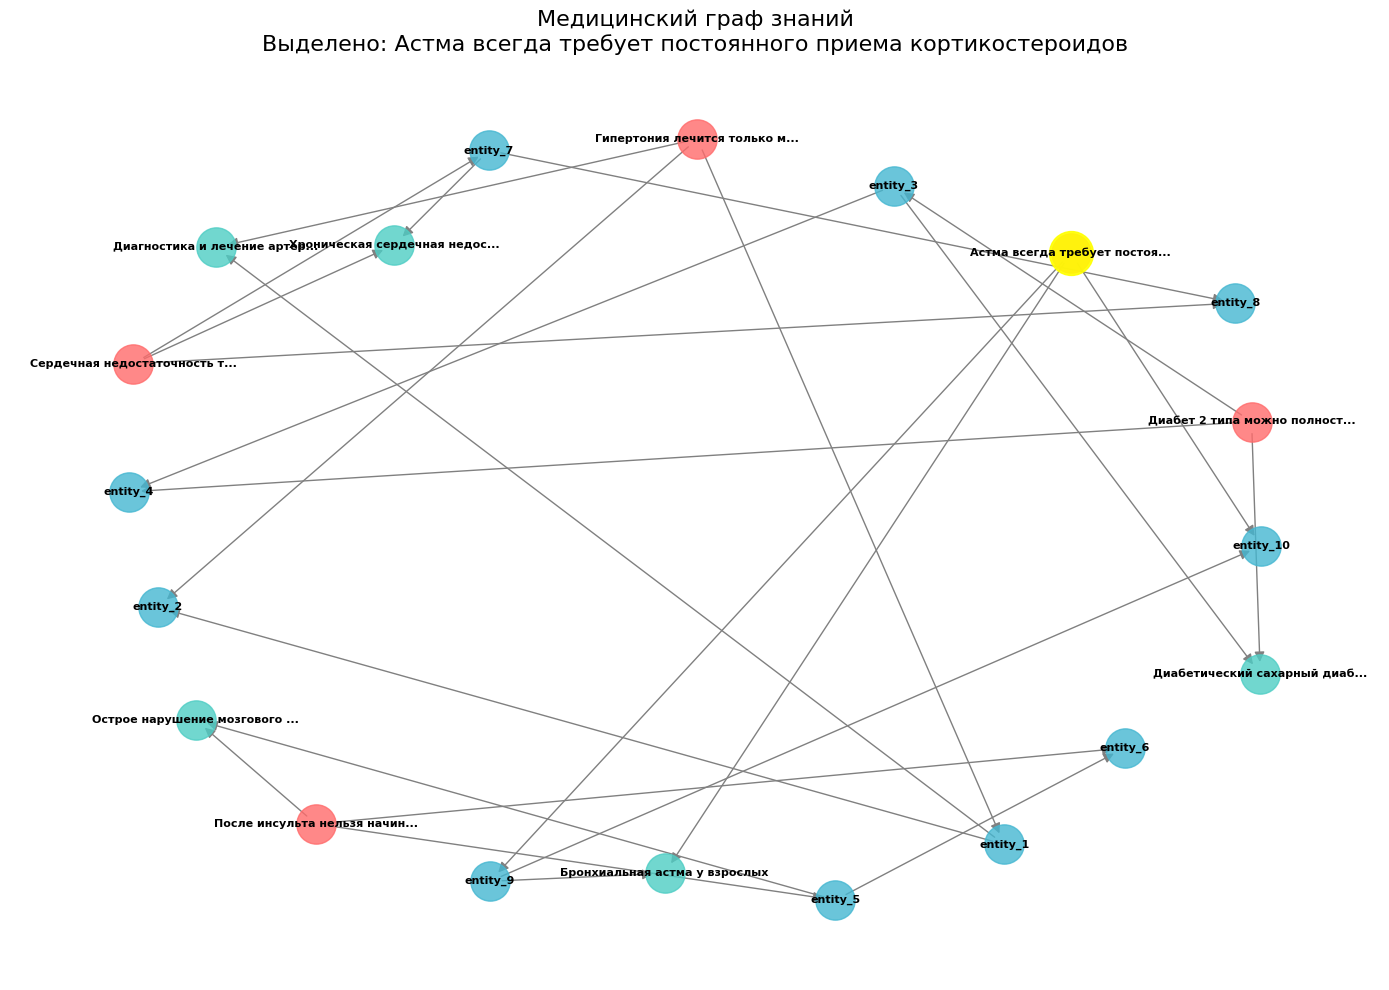



✅ Процесс проверки фактов с HyDE завершен!


In [ ]:
# Russian clinical requirements database (simulated based on cr.minzdrav.gov.ru/clin-rec)
CLINICAL_REQUIREMENTS_DB = {
    "hypertension": {
        "ru": "Диагностика и лечение артериальной гипертензии у взрослых",
        "en": "Diagnosis and Treatment of Arterial Hypertension in Adults",
        "guidelines": [
            "Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. ст.",
            "Рекомендации по фармакотерапии: ингибиторы АПФ, блокаторы кальциевых каналов, диуретики",
            "Целевые значения АД: <130/80 мм рт. ст. для пациентов с СС риском",
            "Мониторинг: регулярное измерение АД, оценка факторов риска"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
        "last_updated": "2023-01-15",
        "evidence_level": "A"
    },
    "diabetes": {
        "ru": "Диабетический сахарный диабет 2 типа",
        "en": "Type 2 Diabetes Mellitus",
        "guidelines": [
            "Диагноз СД2: Гликированный гемоглобин ≥6.5% или уровень глюкозы натощак ≥7.0 ммоль/л",
            "Терапия: метформин как препарат первого выбора",
            "Контроль целей: HbA1c <7% для большинства пациентов",
            "Осложнения: регулярный осмотр глазного дна, оценка нефропатии"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
        "last_updated": "2023-02-20",
        "evidence_level": "A"
    },
    "stroke": {
        "ru": "Острое нарушение мозгового кровообращения",
        "en": "Acute Cerebrovascular Accident",
        "guidelines": [
            "Временные рамки для тромболизиса: в течение 4.5 часов от начала симптомов",
            "Аспирин: начать в первые 24-48 часов после ишемического инсульта",
            "Реабилитация: начать в первые 24-48 часов после стабилизации",
            "Профилактика: антикоагулянты при фибрилляции предсердий"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
        "last_updated": "2023-03-10",
        "evidence_level": "A"
    },
    "heart_failure": {
        "ru": "Хроническая сердечная недостаточность",
        "en": "Chronic Heart Failure",
        "guidelines": [
            "Диагностика: ЭхоКГ, натрийуретические пептиды (BNP/NT-proBNP)",
            "Лечение: ингибиторы АПФ, бета-блокаторы, антагонисты рецепторов ангиотензина II",
            "Классификация: по функции левого желудочка (HFrEF, HFpEF)",
            "Мониторинг: симптомы, вес, ограничение жидкости и соли"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
        "last_updated": "2023-04-05",
        "evidence_level": "A"
    },
    "asthma": {
        "ru": "Бронхиальная астма у взрослых",
        "en": "Bronchial Asthma in Adults",
        "guidelines": [
            "Диагностика: спирометрия, тесты на бронходилатацию, пикфлоуметрия",
            "Терапия: ингаляционные кортикостероиды как основа базисной терапии",
            "Контроль: оценка симптомов, ограничение триггеров, самоконтроль",
            "Экзарбации: системные кортикостероиды, бронходилататоры"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
        "last_updated": "2023-05-12",
        "evidence_level": "A"
    }
}

# Medical knowledge graph database
MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "claim_4": {
            "type": "claim",
            "content": "Сердечная недостаточность требует строгой диеты с ограничением соли",
            "verdict": "supported",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_5": {
            "type": "claim",
            "content": "Астма всегда требует постоянного приема кортикостероидов",
            "verdict": "refuted",
            "confidence": 0.6,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "guideline_4": {
            "type": "guideline",
            "content": "Хроническая сердечная недостаточность",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/heart_failure",
            "last_updated": "2023-04-05",
            "language": "ru"
        },
        "guideline_5": {
            "type": "guideline",
            "content": "Бронхиальная астма у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/asthma",
            "last_updated": "2023-05-12",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        },
        "entity_7": {
            "type": "entity",
            "name": "Сердечная недостаточность",
            "category": "disease",
            "language": "ru"
        },
        "entity_8": {
            "type": "entity",
            "name": "Соль",
            "category": "dietary",
            "language": "ru"
        },
        "entity_9": {
            "type": "entity",
            "name": "Астма",
            "category": "disease",
            "language": "ru"
        },
        "entity_10": {
            "type": "entity",
            "name": "Кортикостероиды",
            "category": "medication",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_4", "target": "entity_7", "relation": "mentions", "weight": 0.9},
        {"source": "claim_4", "target": "entity_8", "relation": "mentions", "weight": 0.8},
        {"source": "claim_4", "target": "guideline_4", "relation": "supports", "weight": 0.95},
        {"source": "claim_5", "target": "entity_9", "relation": "mentions", "weight": 0.8},
        {"source": "claim_5", "target": "entity_10", "relation": "mentions", "weight": 0.7},
        {"source": "claim_5", "target": "guideline_5", "relation": "contradicts", "weight": 0.7},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_7", "target": "guideline_4", "relation": "follows", "weight": 0.9},
        {"source": "entity_9", "target": "guideline_5", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8},
        {"source": "entity_7", "target": "entity_8", "relation": "restricted_by", "weight": 0.7},
        {"source": "entity_9", "target": "entity_10", "relation": "treated_by", "weight": 0.6}
    ]
}

# Define tools for the medical fact-checking system
@tool
def search_clinical_guidelines_ru(condition: str, language: str = "ru") -> str:
    """
    Search Russian clinical guidelines from cr.minzdrav.gov.ru/clin-rec for evidence-based recommendations.
    """
    # Normalize condition name
    condition_lower = condition.lower()

    # Find matching guideline
    matching_guidelines = []
    for key, data in CLINICAL_REQUIREMENTS_DB.items():
        if condition_lower in key.lower() or condition_lower in data["ru"].lower() or condition_lower in data["en"].lower():
            matching_guidelines.append(data)

    if not matching_guidelines:
        return json.dumps({
            "error": f"Не найдено клинических рекомендаций для '{condition}'",
            "available_conditions": list(CLINICAL_REQUIREMENTS_DB.keys()),
            "language": language
        })

    # Return the first matching guideline
    guideline = matching_guidelines[0]

    # Select language-appropriate content
    if language.lower() == "ru":
        content = {
            "condition": guideline["ru"],
            "guidelines": guideline["guidelines"],
            "url": guideline["url"],
            "last_updated": guideline["last_updated"],
            "evidence_level": guideline["evidence_level"],
            "language": "ru"
        }
    else:
        content = {
            "condition": guideline["en"],
            "guidelines": guideline["guidelines"],
            "url": guideline["url"],
            "last_updated": guideline["last_updated"],
            "evidence_level": guideline["evidence_level"],
            "language": "en"
        }

    return json.dumps(content, ensure_ascii=False)

@tool
def get_claim_verification_ru(claim: str, language: str = "ru") -> str:
    """
    Get verification status of a specific medical claim in Russian.
    """
    # In a real implementation, this would query a medical fact-checking database
    claim_lower = claim.lower()

    # Simple pattern matching for demonstration
    if "гипертония" in claim_lower and "медикаментами" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.8,
            "evidence_summary": "Согласно клиническим рекомендациям, лечение гипертонии включает не только медикаменты, но и немедикаментозные методы (диета, физическая активность)",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/hypertension"],
            "language": language
        })
    elif "диабет" in claim_lower and "вылечить" in claim_lower and "диетой" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.9,
            "evidence_summary": "Согласно клиническим рекомендациям, диабет 2 типа не поддается полному излечению, но может быть эффективно контролироваться комплексной терапией",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/diabetes"],
            "language": language
        })
    elif "инсульт" in claim_lower and "реабилитация" in claim_lower and "нельзя" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.7,
            "evidence_summary": "Согласно клиническим рекомендациям, ранняя реабилитация (в первые 24-48 часов) показана после инсульта при стабильном состоянии пациента",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/stroke"],
            "language": language
        })
    elif "сердечная недостаточность" in claim_lower and "соль" in claim_lower and "ограничение" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "SUPPORTED",
            "confidence": 0.9,
            "evidence_summary": "Согласно клиническим рекомендациям, пациентам с сердечной недостаточностью рекомендуется ограничение потребления натрия (соли)",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/heart_failure"],
            "language": language
        })
    elif "астма" in claim_lower and "кортикостероиды" in claim_lower and "постоянный прием" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.6,
            "evidence_summary": "Согласно клиническим рекомендациям, терапия астмы зависит от тяжести заболевания, не все пациенты нуждаются в постоянном приеме кортикостероидов",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/asthma"],
            "language": language
        })
    else:
        return json.dumps({
            "claim": claim,
            "status": "UNVERIFIED",
            "confidence": 0.0,
            "evidence_summary": "Нет верификации для этого утверждения",
            "related_guidelines": [],
            "language": language
        })

@tool
def analyze_claim_graph_structure_ru(claim: str, language: str = "ru") -> str:
    """
    Analyze the knowledge graph structure related to a claim in Russian.
    """
    # Find nodes related to the claim
    related_nodes = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if claim.lower() in node_data.get("content", "").lower():
            related_nodes.append({
                "id": node_id,
                "type": node_data["type"],
                "content": node_data.get("content", ""),
                "properties": {k: v for k, v in node_data.items() if k not in ["type", "content"]},
                "language": node_data.get("language", "ru")
            })

    # Find related edges
    related_edges = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if any(node["id"] == edge["source"] or node["id"] == edge["target"] for node in related_nodes):
            related_edges.append(edge)

    return json.dumps({
        "claim": claim,
        "language": language,
        "graph_nodes": related_nodes,
        "graph_edges": related_edges,
        "node_count": len(related_nodes),
        "edge_count": len(related_edges)
    })

@tool
def query_clinical_knowledge_graph_ru(condition: str, language: str = "ru") -> str:
    """
    Query the medical knowledge graph for related entities and relationships in Russian.
    """
    # Find nodes related to the condition
    condition_node_id = None
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if condition.lower() in node_data.get("content", "").lower():
            condition_node_id = node_id
            break

    if not condition_node_id:
        return json.dumps({"error": f"Не найдена узел для: {condition}", "language": language})

    # Get related nodes and edges
    related_nodes = [condition_node_id]
    related_edges = []

    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] == condition_node_id:
            related_nodes.append(edge["target"])
            related_edges.append(edge)
        elif edge["target"] == condition_node_id:
            related_nodes.append(edge["source"])
            related_edges.append(edge)

    # Get node details
    node_details = []
    for node_id in set(related_nodes):
        node_data = MEDICAL_KNOWLEDGE_GRAPH["nodes"][node_id]
        node_details.append({
            "id": node_id,
            "type": node_data["type"],
            "content": node_data.get("content", ""),
            "language": node_data.get("language", "ru"),
            "properties": {k: v for k, v in node_data.items() if k not in ["type", "content", "language"]}
        })

    return json.dumps({
        "condition": condition,
        "language": language,
        "condition_node_id": condition_node_id,
        "related_nodes": node_details,
        "relationships": related_edges,
        "graph_insights": f"Условие '{condition}' связано с {len(set(related_nodes))-1} другими сущностями через {len(related_edges)} связей"
    })

# Define the HyDE (Hypothetical Document Embeddings) approach
class HyDEApproach:
    """
    Implements HyDE (Hypothetical Document Embeddings) for improved medical fact-checking
    """
    def __init__(self, llm):
        self.llm = llm
        self.hyde_prompt = """Сгенерируйте гипотетический документ, который бы идеально ответил на следующий запрос о медицинской информации.
        Документ должен быть подробным и исчерпывающим, содержащим всю информацию, необходимую для решения медицинского вопроса.

        Запрос: {query}

        Гипотетический документ:"""

    def generate_hypothetical_document(self, query: str) -> str:
        """
        Generate a hypothetical document that would answer the query
        """
        prompt = self.hyde_prompt.format(query=query)
        response = self.llm.invoke([HumanMessage(content=prompt)])
        return response.content.strip()

    def search_with_hyde(self, query: str, search_function) -> List[Dict]:
        """
        Use HyDE approach: Generate hypothetical document, then search with it
        """
        # Generate hypothetical document
        hypothetical_doc = self.generate_hypothetical_document(query)
        print(f"Generated hypothetical document for query: '{query[:50]}...'")
        print(f"Hypothetical doc: {hypothetical_doc[:200]}...")

        # Search using the hypothetical document as the query
        results = search_function(hypothetical_doc)
        return results

# Define the Graph Neural Network for medical claim verification
class MedicalGNN(nn.Module):
    """
    Graph Neural Network for medical claim verification
    """
    def __init__(self, num_node_features, hidden_dim=64, num_classes=3):
        super(MedicalGNN, self).__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Attention mechanism
        self.attention = GATConv(hidden_dim, hidden_dim, heads=4, dropout=0.1)

        # Classification layers
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),  # *4 for multi-head attention
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)  # 3 classes: SUPPORTED, REFUTED, UNVERIFIED
        )

    def forward(self, x, edge_index):
        # Graph convolutions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Attention mechanism
        x = self.attention(x, edge_index)
        x = F.relu(x)

        # Global pooling (mean pooling)
        graph_embedding = torch.mean(x, dim=0, keepdim=True)

        # Classification
        output = self.classifier(graph_embedding)

        return output

# Create the agent that follows the HyDE approach
class MedicalFactCheckingAgent:
    """
    Medical fact-checking agent using HyDE (Hypothetical Document Embeddings) approach
    """
    def __init__(self, llm, tools):
        self.llm = llm
        self.tools = tools
        self.hyde_approach = HyDEApproach(llm)

        # Create the agent executor
        from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
        from langchain_classic.agents.format_scratchpad.openai_tools import format_to_openai_tool_messages
        from langchain_classic.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser

        prompt = ChatPromptTemplate.from_messages([
            ("system", """Вы медицинский ассистент проверки фактов, говорящий на русском языке.
            Используйте подход HyDE (Hypothetical Document Embeddings) для улучшения поиска:
            1. Сгенерируйте гипотетический документ, который бы идеально ответил на запрос пользователя
            2. Используйте этот гипотетический документ для поиска наиболее релевантных источников
            3. Проанализируйте найденные источники и сформируйте ответ

            Доступные инструменты:
            - search_clinical_guidelines_ru: Поиск клинических рекомендаций Минздрава РФ
            - get_claim_verification_ru: Получить статус проверки медицинского утверждения
            - analyze_claim_graph_structure_ru: Анализ структуры графа знаний, связанной с утверждением
            - query_clinical_knowledge_graph_ru: Запрос графа знаний для связанных сущностей и отношений

            Всегда предоставляйте окончательный вердикт на основе собранных доказательств с уровнем достоверности.
            Все ответы должны быть на русском языке."""),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        llm_with_tools = llm.bind_tools(tools)

        agent = (
            {
                "input": lambda x: x["input"],
                "agent_scratchpad": lambda x: format_to_openai_tool_messages(x["intermediate_steps"]),
            }
            | prompt
            | llm_with_tools
            | OpenAIToolsAgentOutputParser()
        )

        self.agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True)

    def fact_check_with_hyde(self, claim: str, language: str = "ru") -> Dict[str, Any]:
        """
        Fact-check a medical claim using HyDE approach
        """
        # First, use HyDE to generate a hypothetical document
        print(f"Generating hypothetical document for: {claim}")
        hypothetical_doc = self.hyde_approach.generate_hypothetical_document(claim)

        # Use the hypothetical document to guide the search
        print(f"Using HyDE to search for relevant guidelines...")
        hyde_search_query = f"{claim} {hypothetical_doc}"

        # Execute the agent with the HyDE-enhanced query
        response = self.agent_executor.invoke({"input": f"Проверьте это медицинское утверждение с использованием подхода HyDE: '{hyde_search_query}'. Следуйте инструкциям HyDE, чтобы проверить утверждение с использованием доступных инструментов. Язык: {language}"})

        return {
            "original_claim": claim,
            "hypothetical_document": hypothetical_doc,
            "response": response["output"]
        }

# Create the graph neural network
def create_medical_gnn():
    """
    Create and initialize the medical GNN
    """
    # Create node features (simplified)
    node_features = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        # Create a simple feature vector based on node properties
        if node_data["type"] == "claim":
            features = [1.0, 0.0, 0.0, node_data.get("confidence", 0.5)]  # [claim, guideline, entity, confidence]
        elif node_data["type"] == "guideline":
            features = [0.0, 1.0, 0.0, 0.8]  # Guidelines have higher inherent confidence
        else:  # entity
            features = [0.0, 0.0, 1.0, 0.5]
        node_features.append(features)

    # Create edge index
    edge_list = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        source_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["source"])
        target_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["target"])
        edge_list.append([source_idx, target_idx])
        # Add reverse edge for undirected graph
        edge_list.append([target_idx, source_idx])

    # Convert to tensor
    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # Create PyTorch Geometric data object
    graph_data = Data(x=x, edge_index=edge_index)

    # Initialize GNN
    gnn = MedicalGNN(num_node_features=4, hidden_dim=64, num_classes=3)

    return gnn, graph_data

# Visualization function for the knowledge graph
def visualize_medical_kg(claim=None):
    """
    Visualize the medical knowledge graph
    """
    G = nx.DiGraph()

    # Add nodes
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        node_type = node_data["type"]
        label = node_data.get("content") or node_data.get("title", node_id)

        # Truncate long labels
        if len(label) > 30:
            label = label[:27] + "..."

        G.add_node(node_id,
                  type=node_type,
                  label=label,
                  language=node_data.get("language", "ru"),
                  content=node_data.get("content", ""))

    # Add edges
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        G.add_edge(edge["source"], edge["target"],
                  relation=edge["relation"],
                  weight=edge["weight"])

    # Create layout
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

    # Define colors for different node types
    node_colors = {
        'claim': '#FF6B6B',      # Red for claims
        'guideline': '#4ECDC4',  # Teal for guidelines
        'entity': '#45B7D1'      # Blue for entities
    }

    # Draw nodes
    for node_type, color in node_colors.items():
        nodes_of_type = [n for n, attr in G.nodes(data=True) if attr['type'] == node_type]
        if nodes_of_type:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes_of_type,
                                 node_color=color, node_size=800, alpha=0.8)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray',
                          arrows=True, arrowsize=15, width=1.0)

    # Draw labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

    # Highlight the claim if specified
    if claim:
        claim_nodes = [n for n, attr in G.nodes(data=True)
                      if claim.lower() in attr.get('content', '').lower() or
                         claim.lower() in attr.get('title', '').lower()]
        if claim_nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=claim_nodes,
                                 node_color='yellow', node_size=1000, alpha=0.9)

    plt.title(f'Медицинский граф знаний\nВыделено: {claim or "Все утверждения"}', size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Main demonstration
def main():
    print("🏥 Медицинская проверка фактов с HyDE и клиническими рекомендациями РФ")
    print("=" * 70)

    # Initialize the agent with HyDE approach
    tools = [search_clinical_guidelines_ru, get_claim_verification_ru,
             analyze_claim_graph_structure_ru, query_clinical_knowledge_graph_ru]
    agent = MedicalFactCheckingAgent(llm, tools)

    # Initialize the GNN
    gnn, graph_data = create_medical_gnn()
    print("✅ Медицинская GNN инициализирована")

    # Example claims to verify (in Russian)
    claims = [
        "Гипертония лечится только медикаментами",
        "Диабет 2 типа можно полностью вылечить диетой",
        "После инсульта нельзя начинать реабилитацию сразу",
        "Сердечная недостаточность требует строгой диеты с ограничением соли",
        "Астма всегда требует постоянного приема кортикостероидов"
    ]

    print("\n🔍 Начало процесса проверки фактов с использованием HyDE...")

    for i, claim in enumerate(claims):
        print(f"Утверждение {i+1}: {claim}")
        print("-" * 50)

        # Step 1: Use the HyDE agent to gather evidence
        print("🤖 Агент с HyDE обрабатывает...")
        result = agent.fact_check_with_hyde(claim, language="ru")

        # Step 2: Run GNN on the knowledge graph for the claim
        print("\n🧬 Запуск анализа нейронной сети...")
        with torch.no_grad():
            gnn_output = gnn(graph_data.x, graph_data.edge_index)
            gnn_prediction = torch.softmax(gnn_output, dim=1)
            gnn_confidence, gnn_class = torch.max(gnn_prediction, dim=1)

            # Map class index to verdict
            class_map = {0: "SUPPORTED", 1: "REFUTED", 2: "UNVERIFIED"}
            gnn_verdict = class_map[gnn_class.item()]
            gnn_confidence = gnn_confidence.item()

        # Step 3: Combine agent and GNN results
        print(f"\n📊 РЕЗУЛЬТАТЫ:")
        print(f"  Гипотетический документ: {result['hypothetical_document'][:100]}...")
        print(f"  Ответ агента: {result['response']}")
        print(f"  Вердикт GNN: {gnn_verdict} (уверенность: {gnn_confidence:.2f})")

        # Step 4: Visualize the knowledge graph for this claim
        print(f"\n🖼️  Визуализация графа знаний для: {claim}")
        visualize_medical_kg(claim)

        print("\n" + "=" * 70 + "\n")

    print("✅ Процесс проверки фактов с HyDE завершен!")

if __name__ == "__main__":
    main()

### 1. Визуализация с использованием алгоритма 'Spring Layout'

**Интерпретация:** Этот алгоритм пытается расположить узлы так, чтобы все ребра имели примерно одинаковую длину, а узлы, не связанные напрямую, были максимально разнесены. Это хорошо подходит для выявления кластеров и наиболее связанных групп узлов. Чем ближе узлы, тем сильнее их связь. Размер узлов зависит от их 'доверия' (confidence), а толщина ребер — от 'веса' (weight) связи. **Вес ребра (edge weight) отражает силу или важность связи между узлами. Большее значение веса приводит к более толстому ребру на визуализации, подчеркивая значимость данной связи.**



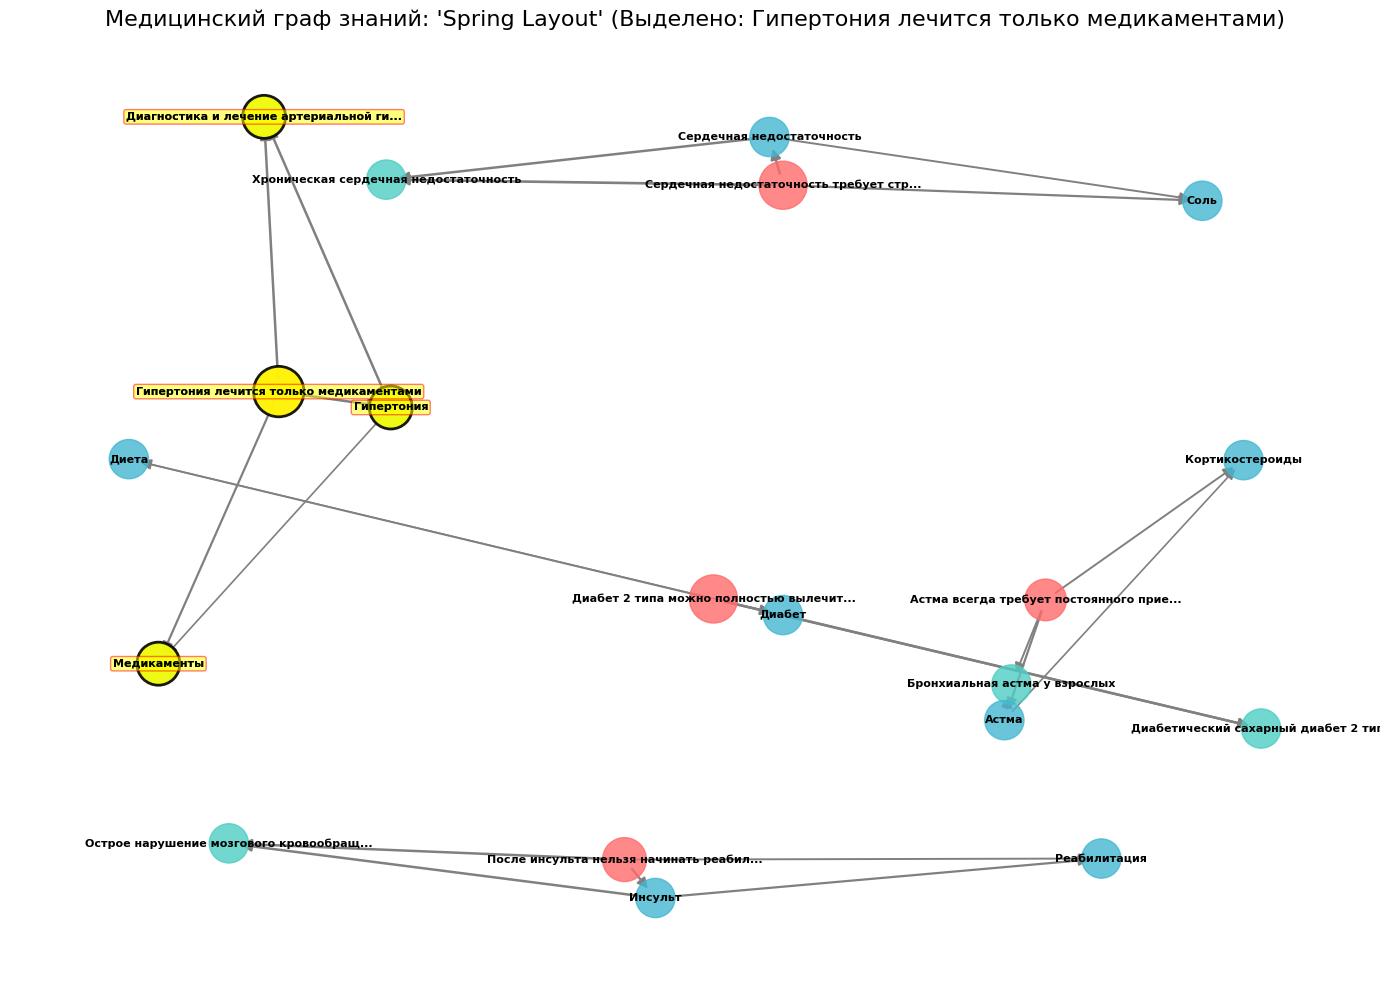



### 2. Визуализация с использованием алгоритма 'Circular Layout'

**Интерпретация:** Узлы располагаются по кругу. Это полезно для отображения симметрии в графе или для ситуаций, когда нет явных кластеров. В этом случае, узлы, относящиеся к одному типу, могут быть сгруппированы для лучшей читаемости, но в целом структура связей менее очевидна, чем в 'Spring Layout'. Размер узлов зависит от степени их связей (degree), все ребра имеют одинаковую толщину.



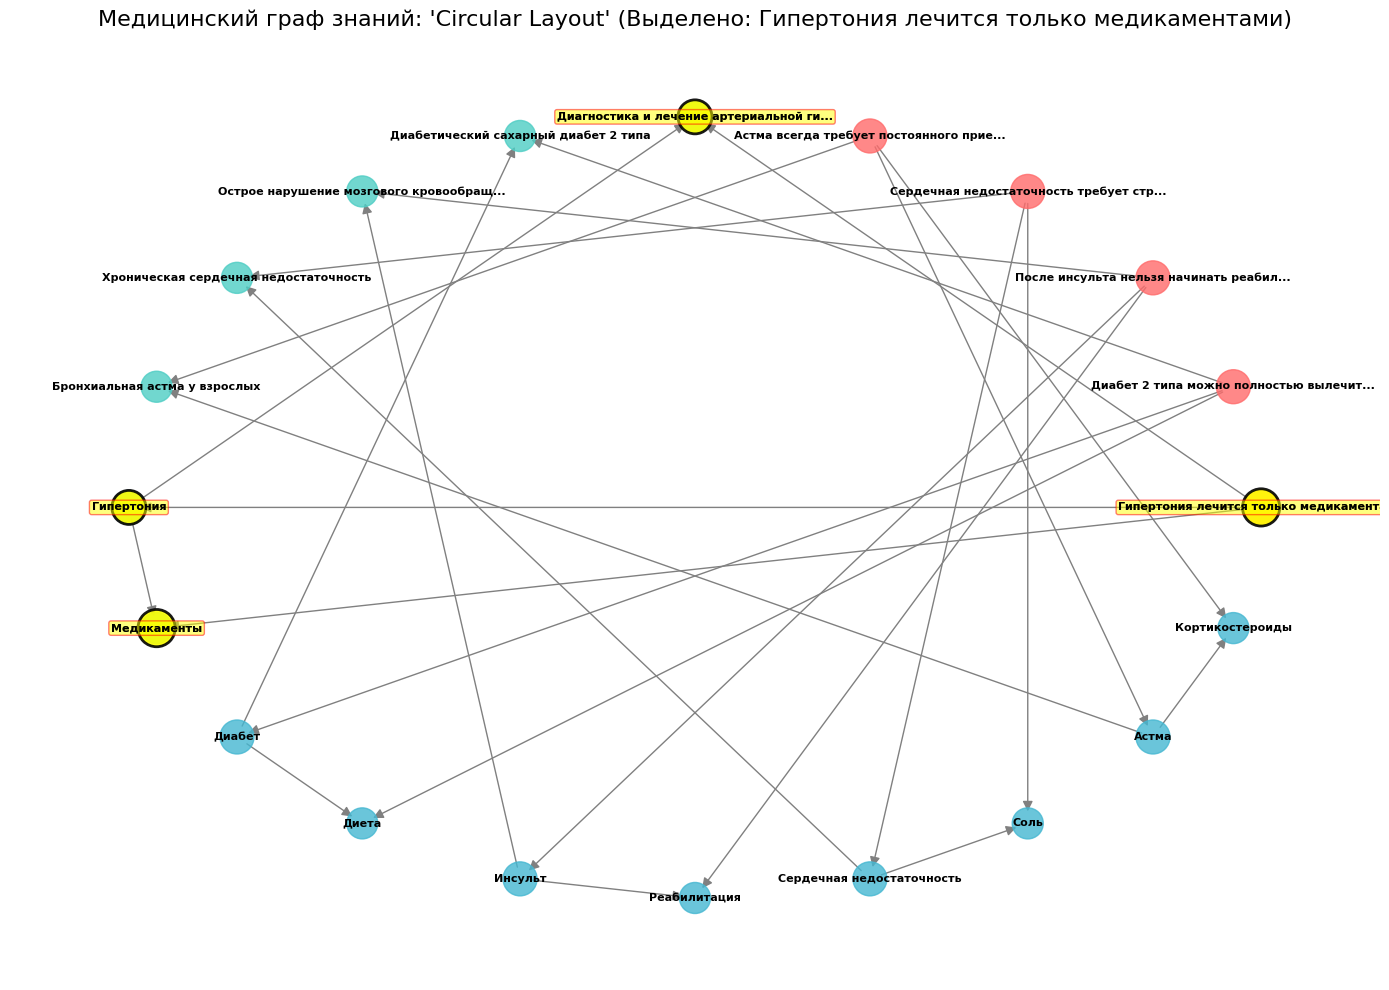



### 3. Визуализация с использованием алгоритма 'Shell Layout'

**Интерпретация:** Узлы располагаются по концентрическим кругам (оболочкам). По умолчанию NetworkX может попытаться разместить узлы, которые имеют похожие степени или принадлежность, на одной оболочке. Это может помочь выявить иерархическую или слоистую структуру графа, если она присутствует. Все узлы имеют одинаковый размер, а толщина ребер пропорциональна их 'весу'.



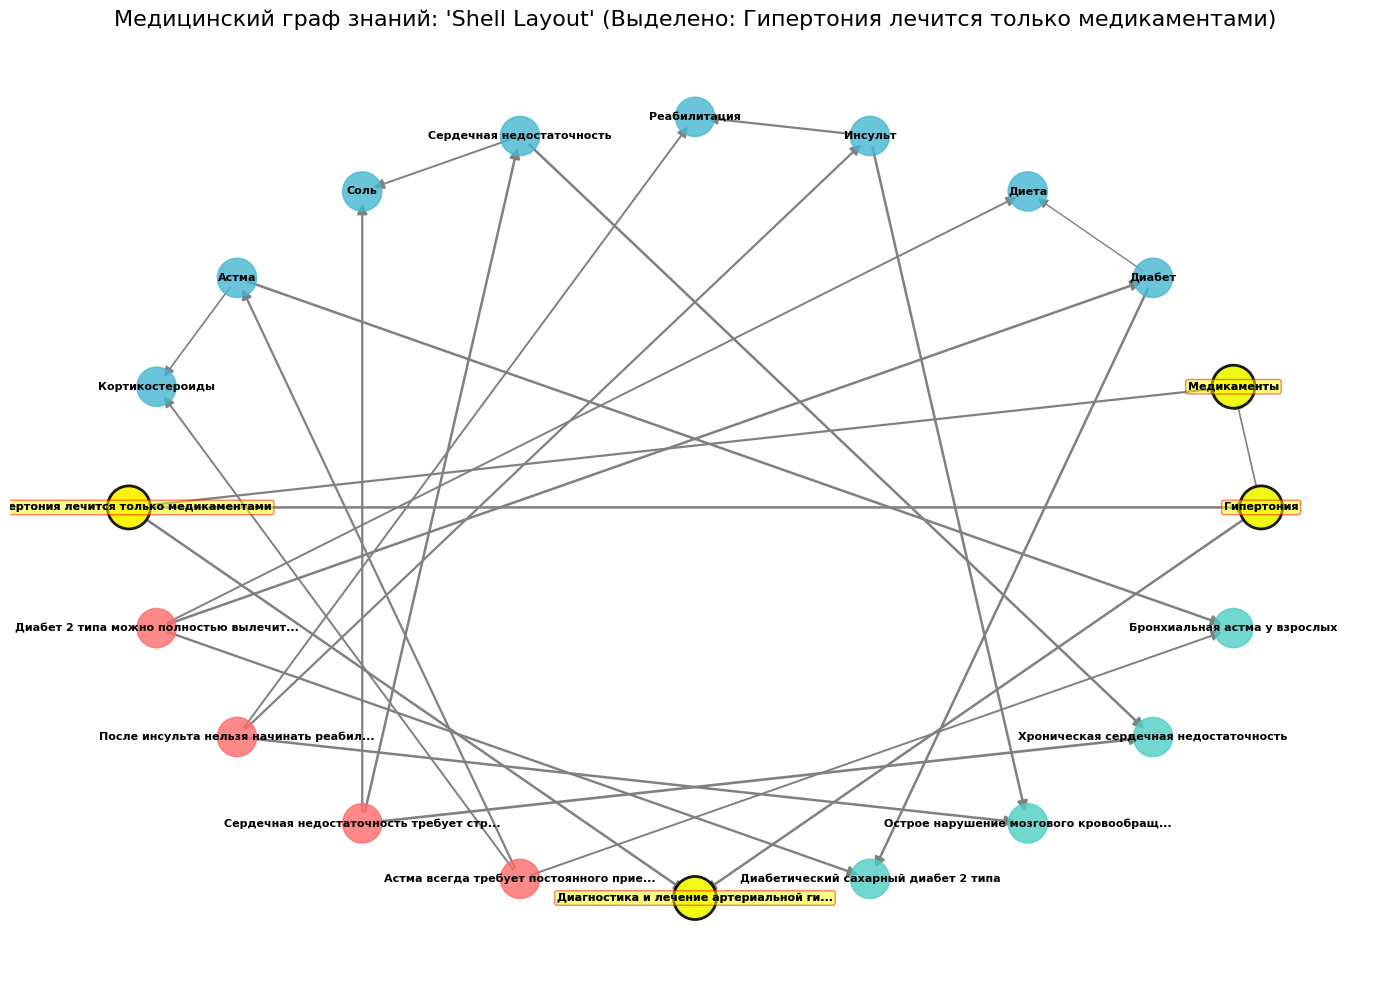



### 4. Визуализация с использованием алгоритма 'Random Layout'

**Интерпретация:** Узлы размещаются случайным образом в пределах заданного пространства. Этот алгоритм не пытается выявить какую-либо структуру и в основном используется для демонстрации полного отсутствия упорядоченности или когда другие алгоритмы не дают желаемого результата. Он может быть полезен для очень плотных графов, чтобы избежать перекрытия, или для начальной оценки без какой-либо специфической интерпретации расположения. Размер узлов зависит от их 'доверия', а толщина ребер — от 'веса'.



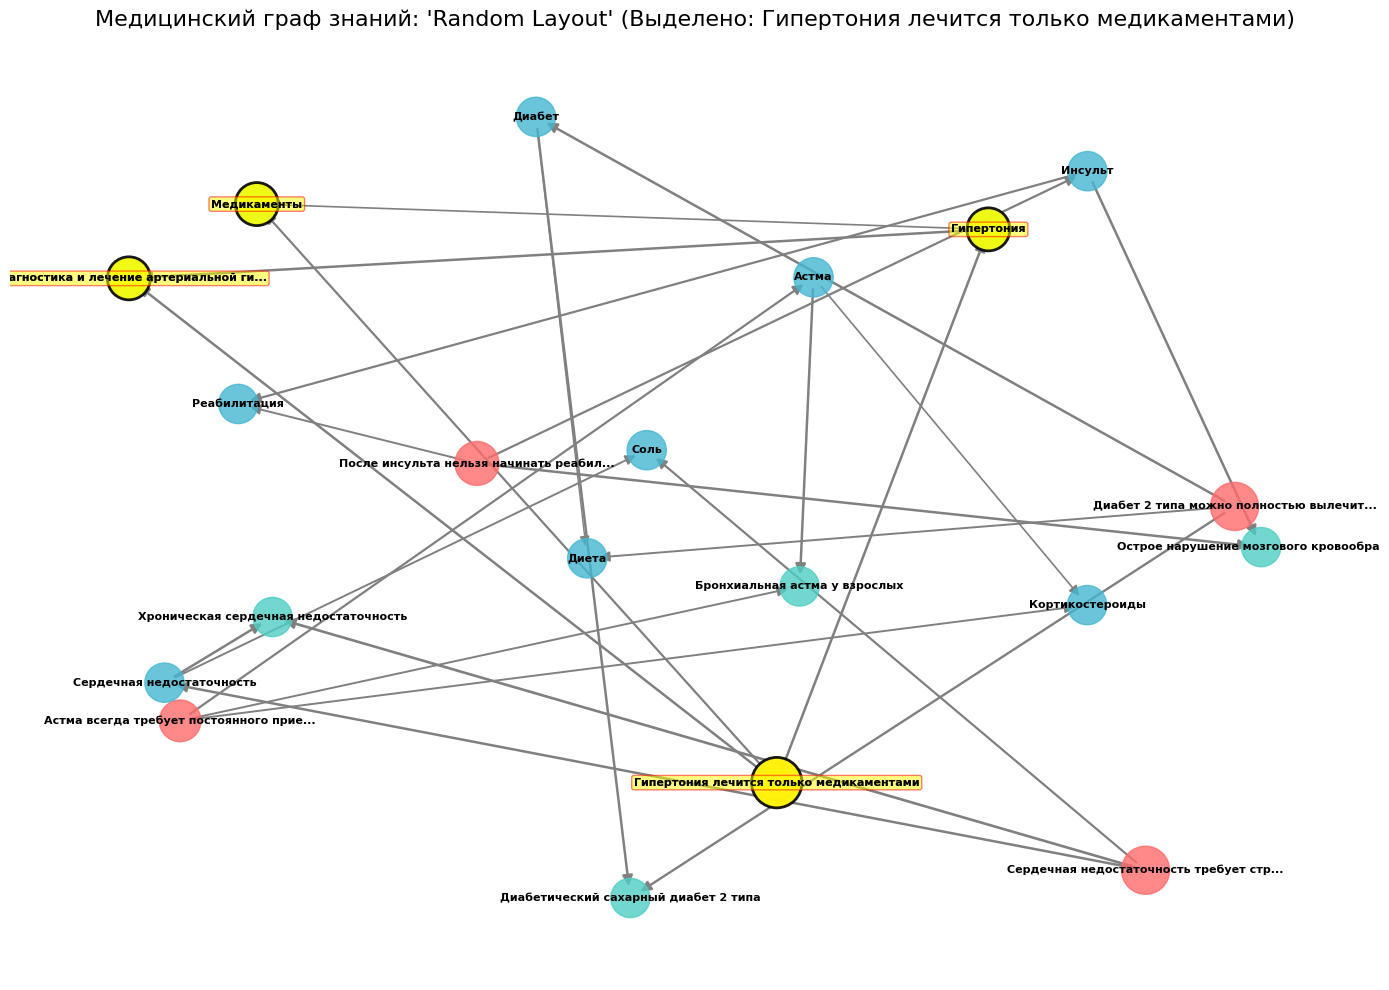

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def get_graph_data_for_visualization():
    G = nx.DiGraph()

    # Add nodes with enhanced attributes for visualization
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        node_type = node_data["type"]
        label = node_data.get("content") or node_data.get("name", node_id)
        if len(label) > 40:
            label = label[:37] + "..."

        G.add_node(node_id,
                  type=node_type,
                  label=label,
                  content=node_data.get("content", ""),
                  name=node_data.get("name", ""),
                  confidence=node_data.get("confidence", 0.5)) # Add confidence for sizing

    # Add edges with attributes
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        G.add_edge(edge["source"], edge["target"],
                  relation=edge["relation"],
                  weight=edge["weight"]) # Add weight for edge width
    return G

def visualize_medical_kg_flexible(
    G,
    layout_type='spring',
    node_size_attribute=None, # e.g., 'degree', 'confidence'
    edge_width_attribute='weight', # e.g., 'weight'
    highlight_nodes=None, # list of node_ids to highlight
    title_suffix="" # Custom title part
):
    plt.figure(figsize=(14, 10))

    # Choose layout algorithm
    if layout_type == 'spring':
        pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)
    elif layout_type == 'circular':
        pos = nx.circular_layout(G)
    elif layout_type == 'shell':
        pos = nx.shell_layout(G)
    elif layout_type == 'random':
        pos = nx.random_layout(G)
    else:
        pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # Default to spring

    # Define colors for different node types
    node_colors_map = {
        'claim': '#FF6B6B',      # Red for claims
        'guideline': '#4ECDC4',  # Teal for guidelines
        'entity': '#45B7D1'      # Blue for entities
    }

    # Get node colors based on type
    node_colors = [node_colors_map.get(G.nodes[n]['type'], '#CCCCCC') for n in G.nodes()]

    # Get node sizes
    node_sizes = []
    if node_size_attribute == 'degree':
        node_sizes = [G.degree(n) * 100 + 300 for n in G.nodes()] # Scale degree
    elif node_size_attribute == 'confidence':
        node_sizes = [G.nodes[n].get('confidence', 0.5) * 1000 + 300 for n in G.nodes()] # Scale confidence
    else:
        node_sizes = [800] * len(G.nodes())

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)

    # Get edge widths
    edge_widths = []
    if edge_width_attribute:
        edge_widths = [G.edges[u, v].get(edge_width_attribute, 1) * 2 for u, v in G.edges()]
    else:
        edge_widths = [1.0] * len(G.edges())

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray',
                          arrows=True, arrowsize=15, width=edge_widths)

    # Draw labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

    # Highlight specified nodes
    if highlight_nodes:
        highlight_n_labels = {n: labels[n] for n in highlight_nodes if n in labels}
        if highlight_nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=highlight_nodes, node_color='yellow', node_size=[s*1.2 for s, n in zip(node_sizes, G.nodes()) if n in highlight_nodes], alpha=0.9, edgecolors='black', linewidths=2)
            nx.draw_networkx_labels(G, pos, highlight_n_labels, font_size=8, font_weight='bold', bbox={"facecolor":"yellow", "alpha":0.5, "edgecolor":"red", "boxstyle":"round,pad=0.2"})

    plt.title(f'Медицинский граф знаний: {title_suffix}', size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def get_nodes_for_claim_highlight(G, claim_text):
    highlight_nodes = []
    for node_id, node_data in G.nodes(data=True):
        if claim_text.lower() in node_data.get('content', '').lower() or \
           claim_text.lower() in node_data.get('name', '').lower() or \
           claim_text.lower() in node_data.get('label', '').lower():
            highlight_nodes.append(node_id)
    # Also find related entities/guidelines directly linked to this claim node
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] in highlight_nodes or edge["target"] in highlight_nodes:
            if edge["source"] not in highlight_nodes: highlight_nodes.append(edge["source"])
            if edge["target"] not in highlight_nodes: highlight_nodes.append(edge["target"])
    return highlight_nodes


# --- Демонстрация различных визуализаций ---

medical_graph = get_graph_data_for_visualization()

print("### 1. Визуализация с использованием алгоритма 'Spring Layout'\n")
print("**Интерпретация:** Этот алгоритм пытается расположить узлы так, чтобы все ребра имели примерно одинаковую длину, а узлы, не связанные напрямую, были максимально разнесены. Это хорошо подходит для выявления кластеров и наиболее связанных групп узлов. Чем ближе узлы, тем сильнее их связь. Размер узлов зависит от их 'доверия' (confidence), а толщина ребер — от 'веса' (weight) связи. **Вес ребра (edge weight) отражает силу или важность связи между узлами. Большее значение веса приводит к более толстому ребру на визуализации, подчеркивая значимость данной связи.**\n")

# Example claim to highlight
claim_to_visualize = "Гипертония лечится только медикаментами"
highlighted_nodes_for_claim = get_nodes_for_claim_highlight(medical_graph, claim_to_visualize)

visualize_medical_kg_flexible(
    medical_graph,
    layout_type='spring',
    node_size_attribute='confidence',
    edge_width_attribute='weight',
    highlight_nodes=highlighted_nodes_for_claim,
    title_suffix=f"'Spring Layout' (Выделено: {claim_to_visualize})"
)

print("\n\n### 2. Визуализация с использованием алгоритма 'Circular Layout'\n")
print("**Интерпретация:** Узлы располагаются по кругу. Это полезно для отображения симметрии в графе или для ситуаций, когда нет явных кластеров. В этом случае, узлы, относящиеся к одному типу, могут быть сгруппированы для лучшей читаемости, но в целом структура связей менее очевидна, чем в 'Spring Layout'. Размер узлов зависит от степени их связей (degree), все ребра имеют одинаковую толщину.\n")
visualize_medical_kg_flexible(
    medical_graph,
    layout_type='circular',
    node_size_attribute='degree',
    edge_width_attribute=None,
    highlight_nodes=highlighted_nodes_for_claim,
    title_suffix=f"'Circular Layout' (Выделено: {claim_to_visualize})"
)

print("\n\n### 3. Визуализация с использованием алгоритма 'Shell Layout'\n")
print("**Интерпретация:** Узлы располагаются по концентрическим кругам (оболочкам). По умолчанию NetworkX может попытаться разместить узлы, которые имеют похожие степени или принадлежность, на одной оболочке. Это может помочь выявить иерархическую или слоистую структуру графа, если она присутствует. Все узлы имеют одинаковый размер, а толщина ребер пропорциональна их 'весу'.\n")
visualize_medical_kg_flexible(
    medical_graph,
    layout_type='shell',
    node_size_attribute=None,
    edge_width_attribute='weight',
    highlight_nodes=highlighted_nodes_for_claim,
    title_suffix=f"'Shell Layout' (Выделено: {claim_to_visualize})"
)

print("\n\n### 4. Визуализация с использованием алгоритма 'Random Layout'\n")
print("**Интерпретация:** Узлы размещаются случайным образом в пределах заданного пространства. Этот алгоритм не пытается выявить какую-либо структуру и в основном используется для демонстрации полного отсутствия упорядоченности или когда другие алгоритмы не дают желаемого результата. Он может быть полезен для очень плотных графов, чтобы избежать перекрытия, или для начальной оценки без какой-либо специфической интерпретации расположения. Размер узлов зависит от их 'доверия', а толщина ребер — от 'веса'.\n")
visualize_medical_kg_flexible(
    medical_graph,
    layout_type='random',
    node_size_attribute='confidence',
    edge_width_attribute='weight',
    highlight_nodes=highlighted_nodes_for_claim,
    title_suffix=f"'Random Layout' (Выделено: {claim_to_visualize})"
)

### Как графы помогают понять связи между узлами и ребрами для медицинских задач

Графы знаний (Knowledge Graphs) представляют собой мощный инструмент для организации и анализа сложной информации, особенно в таких предметных областях, как медицина. Они позволяют визуализировать и исследовать взаимосвязи между различными сущностями, что крайне важно для медицинских задач.

**1. Узлы (Nodes) - Сущности:**

В медицинском графе знаний **узлы** представляют собой конкретные сущности или понятия. Это могут быть:

*   **Заболевания:** (например, "Гипертония", "Диабет 2 типа", "Инсульт")
*   **Симптомы:** (например, "Высокое АД", "Высокий уровень глюкозы")
*   **Лекарства:** (например, "Ингибиторы АПФ", "Метформин", "Кортикостероиды")
*   **Процедуры/Методы лечения:** (например, "Диета", "Реабилитация", "Фармакотерапия")
*   **Клинические рекомендации/Протоколы:** (например, "КР по лечению гипертонии")
*   **Пациенты:** (в более сложных графах)
*   **Гены/Белки/Биомаркеры:** (в биомедицинских графах)
*   **Утверждения/Гипотезы:** (как в данном примере: "Гипертония лечится только медикаментами")

Каждый узел имеет свои атрибуты (например, тип, название, описание, уровень достоверности для утверждений).

**2. Ребра (Edges) - Взаимосвязи:**

**Ребра** соединяют узлы и описывают тип взаимосвязи между ними. Эти связи могут быть направленными и иметь свои атрибуты (например, вес, сила связи, тип отношения). В медицине ребра могут выражать:

*   **Причина/Следствие:** "Высокое АД" (узел) $\rightarrow$ "Гипертония" (узел) (связь "является симптомом")
*   **Лечение/Терапия:** "Гипертония" (узел) $\leftarrow$ "Ингибиторы АПФ" (узел) (связь "лечится с помощью")
*   **Противопоказания/Риски:** "Лекарство X" (узел) $\rightarrow$ "Побочный эффект Y" (узел) (связь "вызывает")
*   **Отношение к рекомендациям:** "Утверждение A" (узел) $\rightarrow$ "Клиническая рекомендация B" (узел) (связь "противоречит", "подтверждается")
*   **Ассоциации:** "Диабет" (узел) $\leftrightarrow$ "Сердечно-сосудистые заболевания" (узел) (связь "связан с повышенным риском")
*   **Меншн:** "Утверждение" (узел) $\rightarrow$ "Сущность" (узел) (связь "упоминает")

**Как это помогает в медицинских задачах:**

1.  **Проверка фактов и обоснование:** Графы позволяют быстро определить, какие клинические рекомендации (узлы) поддерживают или опровергают медицинские утверждения (узлы) через связи "подтверждает" или "противоречит". Вес ребра может указывать на силу этого подтверждения/опровержения.
2.  **Диагностика и принятие решений:** Понимание связей между симптомами, заболеваниями и факторами риска может помочь врачам в постановке диагноза и выборе оптимального курса лечения.
3.  **Поиск и извлечение информации:** Вместо поиска по ключевым словам, графы позволяют выполнять семантический поиск, находя не просто документы, содержащие слова, а связанные понятия и их контекст.
4.  **Исследование и открытие новых знаний:** Анализируя структуру графа (например, плотность связей, центральность узлов), можно выявлять новые, ранее неизвестные взаимосвязи между медицинскими сущностями.
5.  **Персонализированная медицина:** Графы могут учитывать индивидуальные данные пациента (историю болезней, генетику) как узлы и рекомендовать персонализированные подходы к лечению, анализируя их связи с лекарствами и процедурами.

В целом, граф знаний превращает разрозненную медицинскую информацию в структурированную, взаимосвязанную сеть, которую гораздо легче анализировать, визуализировать и использовать для поддержки принятия решений.